In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df= pd.read_csv('/content/fitness.csv')

# EDA
### Inspect the dataset

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1020 entries, 0 to 1019
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             1009 non-null   float64
 1   steps_per_day   1010 non-null   float64
 2   exercise_hours  1010 non-null   float64
 3   water_liters    1010 non-null   float64
 4   fitness_score   1020 non-null   float64
dtypes: float64(5)
memory usage: 40.0 KB


In [ ]:
df.head()

,age,steps_per_day,exercise_hours,water_liters,fitness_score
0,63.0,6148.0,3.7,3.5,35.4
1,36.0,7051.0,14.1,1.6,55.9
2,57.0,8939.0,12.3,1.0,44.1
3,61.0,14898.0,1.6,1.8,55.7
4,61.0,9802.0,0.0,0.8,24.9


In [ ]:
df.describe()

,age,steps_per_day,exercise_hours,water_liters,fitness_score
count,1009.000000,1010.000000,1010.000000,1010.000000,1020.000000
mean,41.291378,10175.541584,7.430198,2.759208,48.482941
std,13.590246,5553.645616,4.341076,1.529855,17.258258
min,18.000000,-100.000000,-2.000000,0.500000,4.200000
25%,30.000000,5356.000000,3.900000,1.600000,35.375000
50%,41.000000,9941.000000,7.450000,2.700000,48.450000
75%,53.000000,15069.750000,11.100000,3.800000,60.900000
max,64.000000,19993.000000,15.000000,15.000000,90.000000


## Find missing values and duplicates

In [ ]:
df.isnull().sum()

,0
age,11
steps_per_day,10
exercise_hours,10
water_liters,10
fitness_score,0


In [ ]:
df.duplicated().sum()

np.int64(20)

## Identify -ve steps, -ve exercise hours, and unrealistic water intake

In [ ]:
invalid_steps = df[df['steps_per_day'] < 0]
invalid_exercise_hours = df[df['exercise_hours'] < 0]
unrealistic_water_intake = df[df['water_liters'] < 0]

In [ ]:
invalid_steps

,age,steps_per_day,exercise_hours,water_liters,fitness_score
155,57.0,-100.0,8.5,4.7,46.7
173,20.0,-100.0,5.4,2.6,49.5
498,41.0,-100.0,14.3,3.5,55.0
776,32.0,-100.0,7.7,3.0,23.6
870,27.0,-100.0,6.3,4.2,48.3


In [ ]:
invalid_exercise_hours

,age,steps_per_day,exercise_hours,water_liters,fitness_score
141,29.0,16239.0,-2.0,4.0,80.5
176,46.0,6682.0,-2.0,2.1,40.9
204,37.0,5878.0,-2.0,4.6,50.2
357,20.0,10246.0,-2.0,2.4,46.4
585,20.0,10246.0,-2.0,2.4,46.4
663,44.0,17086.0,-2.0,1.5,50.3


In [ ]:
unrealistic_water_intake

,age,steps_per_day,exercise_hours,water_liters,fitness_score


## Check fitness-score outliers

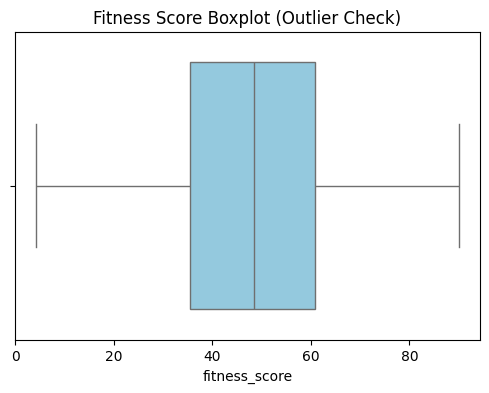

Number of fitness_score outliers detected: 0


In [ ]:
plt.figure(figsize=(6, 4))
sns.boxplot(x=df["fitness_score"], color="skyblue")
plt.title("Fitness Score Boxplot (Outlier Check)")
plt.show()

Q1 = df["fitness_score"].quantile(0.25)
Q3 = df["fitness_score"].quantile(0.75)
IQR = Q3 - Q1

outliers = df[
    (df["fitness_score"] < (Q1 - 1.5 * IQR))
    | (df["fitness_score"] > (Q3 + 1.5 * IQR))
]
print(f"Number of fitness_score outliers detected: {len(outliers)}")

## Plot steps & exercise-hours distributions

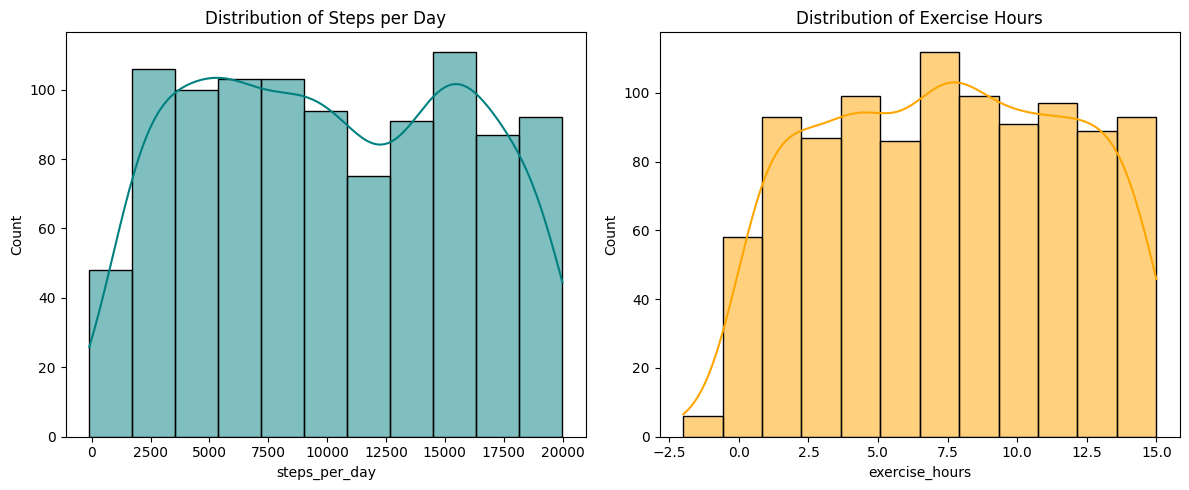

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(df["steps_per_day"], kde=True, ax=axes[0], color="teal")
axes[0].set_title("Distribution of Steps per Day")

sns.histplot(df["exercise_hours"], kde=True, ax=axes[1], color="orange")
axes[1].set_title("Distribution of Exercise Hours")

plt.tight_layout()
plt.show()

 ## Analyze relationships with fitness score




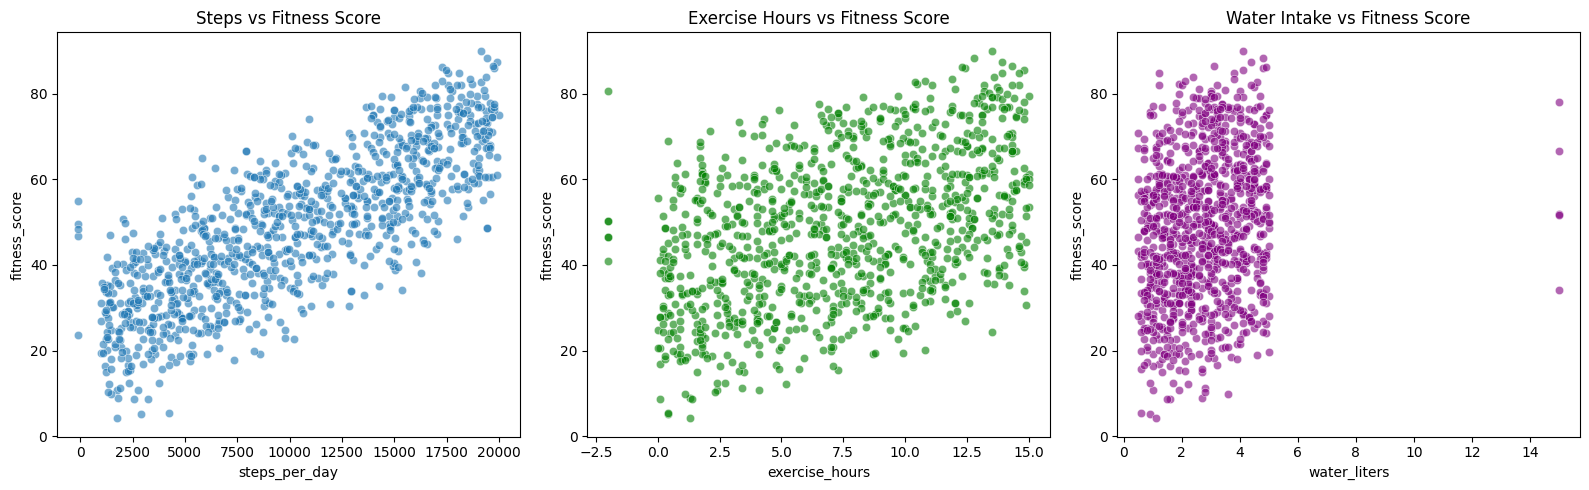

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
sns.scatterplot(
    data=df, x="steps_per_day", y="fitness_score", ax=axes[0], alpha=0.6
)
axes[0].set_title("Steps vs Fitness Score")

sns.scatterplot(
    data=df, x="exercise_hours", y="fitness_score", ax=axes[1], color="green", alpha=0.6
)
axes[1].set_title("Exercise Hours vs Fitness Score")

sns.scatterplot(
    data=df, x="water_liters", y="fitness_score", ax=axes[2], color="purple", alpha=0.6
)
axes[2].set_title("Water Intake vs Fitness Score")

plt.tight_layout()
plt.show()

## Create a correlation heatmap

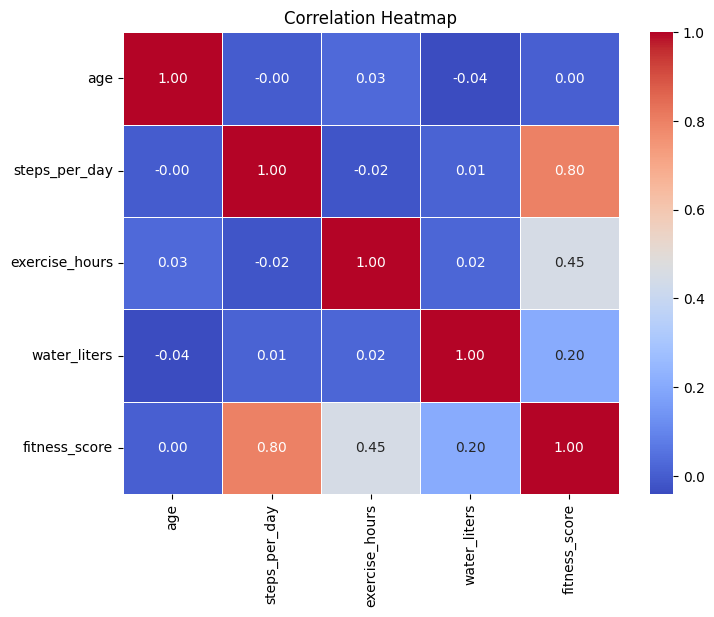

In [ ]:
plt.figure(figsize=(8, 6))
correlation_matrix = df.corr(numeric_only=True)

sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

# Data Cleaning & Feature Engineering

### Clean the data

In [ ]:
df_clean = df.copy()
len(df_clean)

1020

In [ ]:
df_clean = df_clean.drop_duplicates()
len(df_clean)

1000

In [ ]:
df_clean[df_clean['steps_per_day'] >= 0]
df_clean[df_clean['exercise_hours'] >= 0]
df_clean[(df_clean["water_liters"] >= 0) & (df_clean["water_liters"] <= 15)]
len(df_clean)

960

### Fill Missing Values

In [ ]:
df_clean.fillna(df_clean.median(numeric_only=True))
df_clean.isnull().sum()

,0
age,9
steps_per_day,0
exercise_hours,0
water_liters,0
fitness_score,0


In [ ]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 960 entries, 0 to 1019
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             951 non-null    float64
 1   steps_per_day   960 non-null    float64
 2   exercise_hours  960 non-null    float64
 3   water_liters    960 non-null    float64
 4   fitness_score   960 non-null    float64
dtypes: float64(5)
memory usage: 45.0 KB


In [ ]:
df_clean.head()

,age,steps_per_day,exercise_hours,water_liters,fitness_score
0,63.0,6148.0,3.7,3.5,35.4
1,36.0,7051.0,14.1,1.6,55.9
2,57.0,8939.0,12.3,1.0,44.1
3,61.0,14898.0,1.6,1.8,55.7
4,61.0,9802.0,0.0,0.8,24.9


### Create activity_score

In [ ]:
df_clean["activity_score"] = (df_clean["steps_per_day"] / 1000) + (
    df_clean["exercise_hours"] * 2)
df_clean[["steps_per_day", "exercise_hours", "activity_score"]].head()

,steps_per_day,exercise_hours,activity_score
0,6148.0,3.7,13.548
1,7051.0,14.1,35.251
2,8939.0,12.3,33.539
3,14898.0,1.6,18.098
4,9802.0,0.0,9.802


### Create one additional useful feature

In [ ]:
# exercise hours per decade of age
df_clean["exercise_per_age_ratio"] = df_clean["exercise_hours"] / (
df_clean["age"] / 10)

In [ ]:
df_clean[["age", "exercise_hours", "exercise_per_age_ratio"]].head()

,age,exercise_hours,exercise_per_age_ratio
0,63.0,3.7,0.587302
1,36.0,14.1,3.916667
2,57.0,12.3,2.157895
3,61.0,1.6,0.262295
4,61.0,0.0,0.000000


### Use fitness_score as the target and separate $X$ and $y$

In [ ]:
y = df_clean["fitness_score"]
X = df_clean.drop(columns=["fitness_score"])

print("X shape (Features):", X.shape)
print("y shape (Target):", y.shape)

X shape (Features): (960, 6)
y shape (Target): (960,)
